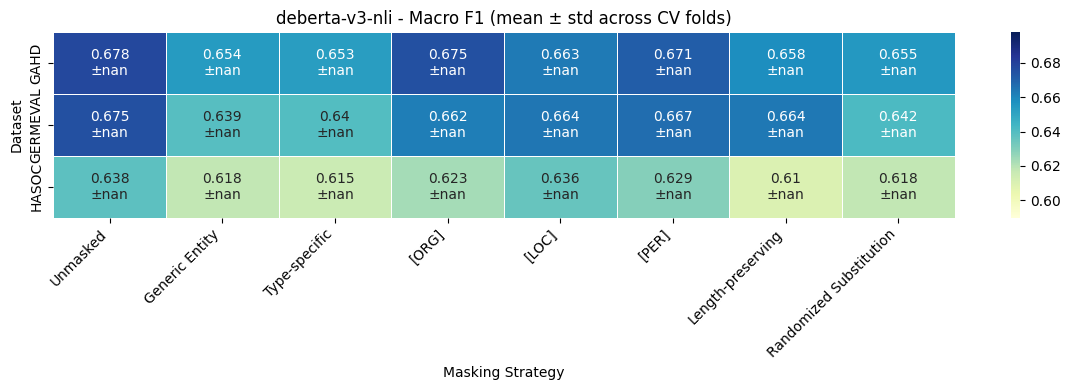

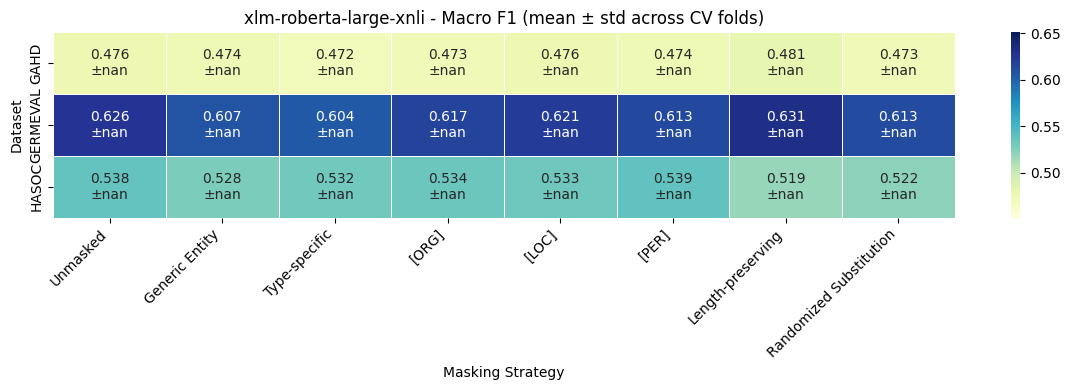


Average F1 per strategy:

Strategy
Unmasked                   0.604963
[LOC]                      0.598989
[PER]                      0.598925
[ORG]                      0.597622
Length-preserving          0.593842
Randomized Substitution    0.587116
Generic Entity             0.586602
Type-specific              0.586114
Name: F1_macro, dtype: float64


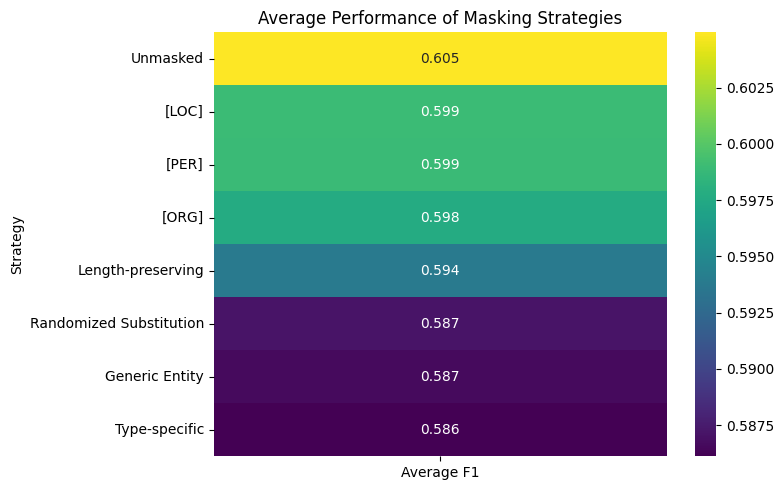

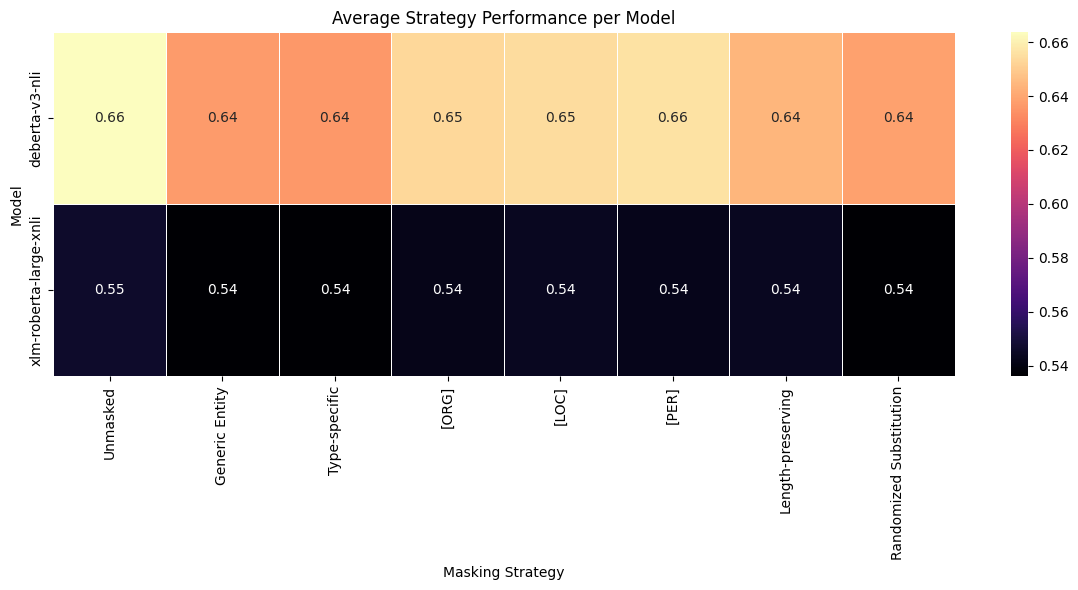

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# LOAD DATA
# -----------------------------
import csv, io
import pandas as pd

with open('RESULTS.csv', encoding='utf-8', newline='') as f:
    raw = f.read()

lines = [l for l in raw.split('\r\n') if l != '']
header, data_lines = lines[0], lines[1:]

# strip outer quote wrapper + undo one level of doubled quotes
unwrapped = [l[1:-1].replace('""', '"') for l in data_lines]
text = header + '\n' + '\n'.join(unwrapped)

df = pd.read_csv(io.StringIO(text))

new_order = [
    "Unmasked",
    "Placeholder",
    "Type-specific",
    "[ORG]",
    "[LOC]",
    "[PER]",
    "Length",
    "Random",
]

# Optional prettier labels for plots
pretty_labels = {
    "Unmasked": "Unmasked",
    "Placeholder": "Generic Entity",
    "Type-specific": "Type-specific",
    "[ORG]": "[ORG]",
    "[LOC]": "[LOC]",
    "[PER]": "[PER]",
    "Length": "Length-preserving",
    "Random": "Randomized Substitution",
}

# Map raw CSV strategy codes -> short strategy keys used above
strategy_map = {
    "PER_ORG_LOC_GENERIC_ENTITY": "Placeholder",
    "PER_ORG_LOC_TYPED": "Type-specific",
    "ORG_ONLY": "[ORG]",
    "LOC_ONLY": "[LOC]",
    "PER_ONLY": "[PER]",
    "X_LENGTH": "Length",
    "RANDOM_SUBSTITUTION": "Random",
    # If/when an unmasked baseline is added to the CSV, map its code here, e.g.:
    "UNMASKED": "Unmasked",
}

df["Strategy"] = df["Strategy"].map(strategy_map).fillna(df["Strategy"])

# Only keep strategies that are both mapped and actually present in the data,
# in the requested order
strategies = [s for s in new_order if s in df["Strategy"].unique()]
missing = [s for s in new_order if s not in strategies]
if missing:
    print(f"Note: no data found for strategies: {missing} (skipped)")

# Optional: nicer model display names
model_name_map = {
    "BERT_GERMAN": "bert-base-german-cased",
    "GBERT": "gbert-base",
    "GELECTRA_BASE": "gelectra-base",
    "XLM_ROBERTA": "xlm-roberta-base",
    "XLM_ROBERTA_LARGE": "xlm-roberta-large",
}
df["Model"] = df["Model"].map(model_name_map).fillna(df["Model"])

# -----------------------------
# AGGREGATE ACROSS CV FOLDS
# -----------------------------

agg = (
    df.groupby(["Model", "Dataset", "Strategy"])["F1_macro"]
    .agg(["mean", "std"])
    .reset_index()
)

# -----------------------------
# HEATMAPS MODEL-WISE (mean F1, annotated with mean ± std)
# -----------------------------

for model_name in agg["Model"].unique():

    model_agg = agg[agg["Model"] == model_name]

    mean_df = model_agg.pivot(index="Dataset", columns="Strategy", values="mean")
    std_df = model_agg.pivot(index="Dataset", columns="Strategy", values="std")

    # reorder columns per new_order, use pretty labels
    mean_df = mean_df[strategies].rename(columns=pretty_labels)
    std_df = std_df[strategies].rename(columns=pretty_labels)

    annot = mean_df.round(3).astype(str) + "\n±" + std_df.round(3).astype(str)

    plt.figure(figsize=(12, 4))

    sns.heatmap(
        mean_df,
        annot=annot,
        fmt="",
        cmap="YlGnBu",
        linewidths=0.5,
        vmin=mean_df.values.min() - 0.02,
        vmax=mean_df.values.max() + 0.02,
    )

    plt.title(f"{model_name} - Macro F1 (mean ± std across CV folds)")
    plt.xlabel("Masking Strategy")
    plt.ylabel("Dataset")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    plt.savefig(f"{model_name}_heatmap_masked.png", dpi=1200,bbox_inches="tight")
    plt.show()

# -----------------------------
# STRATEGY-WISE AVERAGE (mean across all models/datasets/folds)
# -----------------------------

strategy_avg = (
    df[df["Strategy"].isin(strategies)]
    .groupby("Strategy")["F1_macro"]
    .mean()
    .reindex(strategies)
    .rename(index=pretty_labels)
    .sort_values(ascending=False)
)

print("\nAverage F1 per strategy:\n")
print(strategy_avg)

plt.figure(figsize=(8, 5))

sns.heatmap(
    strategy_avg.to_frame(name="Average F1"),
    annot=True,
    cmap="viridis",
    fmt=".3f",
)

plt.title("Average Performance of Masking Strategies")
plt.tight_layout()

plt.savefig("average_performance_of_masking_strategies.png", dpi=1200, bbox_inches="tight")
plt.show()

# -----------------------------
# MODEL COMPARISON (mean F1 per model x strategy, averaged across datasets/folds)
# -----------------------------

model_avg = (
    df[df["Strategy"].isin(strategies)]
    .groupby(["Model", "Strategy"])["F1_macro"]
    .mean()
    .unstack("Strategy")[strategies]
    .rename(columns=pretty_labels)
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    model_avg,
    annot=True,
    cmap="magma",
    fmt=".2f",
    linewidths=0.5,
)

plt.title("Average Strategy Performance per Model")
plt.xlabel("Masking Strategy")
plt.ylabel("Model")
plt.tight_layout()

plt.savefig("average_performance_of_masking_strategies.png", dpi=1200, bbox_inches="tight")
plt.show()




In [2]:
df

,Model,Dataset,Strategy,N,Accuracy,Precision_macro,Recall_macro,F1_macro,Weighted_F1,Class0_Precision,Class0_Recall,Class0_F1,Class0_Support,Class1_Precision,Class1_Recall,Class1_F1,Class1_Support
0,xlm-roberta-large-xnli,GERMEVAL,Unmasked,8407,0.697395,0.654932,0.620742,0.625719,0.678926,0.732085,0.856707,0.789509,5569.0,0.577778,0.384778,0.461929,2838.0
1,xlm-roberta-large-xnli,GERMEVAL,Placeholder,8407,0.692637,0.648954,0.604883,0.607079,0.666640,0.720751,0.875022,0.790430,5569.0,0.577157,0.334743,0.423729,2838.0
2,xlm-roberta-large-xnli,GERMEVAL,[PER],8407,0.695492,0.653101,0.610061,0.613239,0.671179,0.724051,0.873047,0.791599,5569.0,0.582151,0.347075,0.434879,2838.0
3,xlm-roberta-large-xnli,GERMEVAL,[ORG],8407,0.695016,0.651827,0.613504,0.617480,0.673425,0.726861,0.864428,0.789698,5569.0,0.576794,0.362579,0.445262,2838.0
4,xlm-roberta-large-xnli,GERMEVAL,[LOC],8407,0.695135,0.651760,0.616704,0.621208,0.675568,0.729396,0.858143,0.788549,5569.0,0.574124,0.375264,0.453867,2838.0
5,xlm-roberta-large-xnli,GERMEVAL,Type-specific,8407,0.693946,0.651803,0.602846,0.604155,0.665398,0.718942,0.883282,0.792684,5569.0,0.584665,0.322410,0.415626,2838.0
6,xlm-roberta-large-xnli,GERMEVAL,Length,8407,0.687284,0.642945,0.626589,0.631056,0.677844,0.740196,0.813431,0.775088,5569.0,0.545693,0.439746,0.487024,2838.0
7,xlm-roberta-large-xnli,GERMEVAL,Random,8407,0.683954,0.636036,0.608955,0.612795,0.666717,0.726017,0.839828,0.778786,5569.0,0.546056,0.378083,0.446804,2838.0
8,xlm-roberta-large-xnli,HASOC,Unmasked,4594,0.737919,0.538632,0.564336,0.537537,0.769991,0.899075,0.791656,0.841953,4051.0,0.178189,0.337017,0.233121,543.0
9,xlm-roberta-large-xnli,HASOC,Placeholder,4594,0.737701,0.529800,0.548265,0.527780,0.768199,0.894620,0.796347,0.842628,4051.0,0.164980,0.300184,0.212933,543.0
